# Cotton Leaf Disease Detection — Full Training Pipeline
Run cells in order. Cell 4 requires you to inspect your dataset path and update `CONFIG['dataset_dir']` in Cell 5 accordingly.

## Cell 1 — Install missing packages

In [106]:
!pip install -q onnx onnxruntime
import onnxruntime
print(onnxruntime.__version__)

1.30.0


## Cell 2 — Imports

In [107]:
import os
import sys
import json
import random
import shutil
import copy
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

import onnx
import onnxruntime as ort

from PIL import Image
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

## Cell 3 — Reproducibility & device

In [108]:
SEED = 42

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"[INFO] GPU: {torch.cuda.get_device_name(0)}")

[INFO] Using device: cpu


## Cell 4 — Inspect your dataset's actual folder path
Run this first and find the folder that contains subfolders named after disease classes (e.g. `Healthy`, `Bacterial Blight`, etc). Copy that exact path into Cell 5.

In [109]:
for root, dirs, files in os.walk("/kaggle/input/datasets/seroshkarim/cotton-leaf-disease-dataset"):
    depth = root.count(os.sep) - "/kaggle/input/datasets/seroshkarim/cotton-leaf-disease-dataset".count(os.sep)
    if depth <= 3:
        print("  " * depth + root, "->", dirs[:10], files[:2])

/kaggle/input/datasets/seroshkarim/cotton-leaf-disease-dataset -> ['cotton'] []
  /kaggle/input/datasets/seroshkarim/cotton-leaf-disease-dataset/cotton -> ['fussarium_wilt', 'curl_virus', 'healthy', 'bacterial_blight'] []
    /kaggle/input/datasets/seroshkarim/cotton-leaf-disease-dataset/cotton/fussarium_wilt -> [] ['fus310.JPG', 'fus207.jpg']
    /kaggle/input/datasets/seroshkarim/cotton-leaf-disease-dataset/cotton/curl_virus -> [] ['curl110.jpg', 'curl283.jpg']
    /kaggle/input/datasets/seroshkarim/cotton-leaf-disease-dataset/cotton/healthy -> [] ['h66.jpg', 'h418.jpg']
    /kaggle/input/datasets/seroshkarim/cotton-leaf-disease-dataset/cotton/bacterial_blight -> [] ['bact116.jpg', 'bact147.png']


## Cell 5 — Config
Update `dataset_dir` with the path found in Cell 4.

In [110]:
CONFIG = {
    "dataset_dir": "/kaggle/input/datasets/seroshkarim/cotton-leaf-disease-dataset/cotton",
    "work_dir": "/kaggle/working/cotton_pipeline_output",
    "img_size": 224,
    "batch_size": 32,
    "num_workers": 2,
    "train_split": 0.8,
    "val_split": 0.1,
    "test_split": 0.1,
    "num_epochs": 5,
    "learning_rate": 3e-4,
    "weight_decay": 1e-4,
    "label_smoothing": 0.1,
    "early_stopping_patience": 5,
    "lr_scheduler_patience": 2,
    "lr_scheduler_factor": 0.5,
    "dropout": 0.3,
    "backbone": "mobilenet_v3_large",
    "unfreeze_last_n_blocks": 3,
    "seed": SEED,
}

os.makedirs(CONFIG["work_dir"], exist_ok=True)
CHECKPOINT_PATH = os.path.join(CONFIG["work_dir"], "cotton_model_best.pt")
ONNX_PATH = os.path.join(CONFIG["work_dir"], "cotton_model.onnx")
CLASSES_JSON_PATH = os.path.join(CONFIG["work_dir"], "classes.json")
HISTORY_JSON_PATH = os.path.join(CONFIG["work_dir"], "training_history.json")

## Cell 6 — Transforms

In [111]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=25),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

## Cell 7 — Data functions

In [112]:
def discover_classes_and_save(dataset_dir: str, out_json_path: str) -> dict:
    if not os.path.isdir(dataset_dir):
        raise FileNotFoundError(
            f"Dataset directory not found: {dataset_dir}. "
            f"Update CONFIG['dataset_dir'] using the path printed in Cell 4."
        )
    class_names = sorted(
        d for d in os.listdir(dataset_dir)
        if os.path.isdir(os.path.join(dataset_dir, d))
    )
    if len(class_names) == 0:
        raise ValueError(f"No class subdirectories found under {dataset_dir}")
    class_mapping = {str(i): name for i, name in enumerate(class_names)}
    with open(out_json_path, "w") as f:
        json.dump(class_mapping, f, indent=4)
    print(f"[INFO] Discovered {len(class_names)} classes: {class_names}")
    print(f"[INFO] Saved class mapping to {out_json_path}")
    return class_mapping


def build_stratified_splits(full_dataset: datasets.ImageFolder, config: dict):
    targets = np.array(full_dataset.targets)
    indices = np.arange(len(targets))
    train_idx, temp_idx, train_y, temp_y = train_test_split(
        indices, targets,
        test_size=(1.0 - config["train_split"]),
        stratify=targets, random_state=config["seed"],
    )
    relative_val_frac = config["val_split"] / (config["val_split"] + config["test_split"])
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=(1.0 - relative_val_frac),
        stratify=temp_y, random_state=config["seed"],
    )
    print(f"[INFO] Split sizes -> Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")
    return train_idx, val_idx, test_idx


class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = indices
        self.transform = transform
        self.samples = [base_dataset.samples[i] for i in indices]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        image = self.transform(image)
        return image, label


def build_dataloaders(config: dict):
    class_mapping = discover_classes_and_save(config["dataset_dir"], CLASSES_JSON_PATH)
    num_classes = len(class_mapping)
    base_dataset = datasets.ImageFolder(root=config["dataset_dir"])
    train_idx, val_idx, test_idx = build_stratified_splits(base_dataset, config)

    train_dataset = TransformedSubset(base_dataset, train_idx, train_transform)
    val_dataset = TransformedSubset(base_dataset, val_idx, eval_transform)
    test_dataset = TransformedSubset(base_dataset, test_idx, eval_transform)

    train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True,
                               pin_memory=True, num_workers=config["num_workers"])
    val_loader = DataLoader(val_dataset, batch_size=config["batch_size"], shuffle=False,
                             pin_memory=True, num_workers=config["num_workers"])
    test_loader = DataLoader(test_dataset, batch_size=config["batch_size"], shuffle=False,
                              pin_memory=True, num_workers=config["num_workers"])
    return train_loader, val_loader, test_loader, class_mapping, num_classes

## Cell 8 — Build the dataloaders

In [113]:
train_loader, val_loader, test_loader, class_mapping, num_classes = build_dataloaders(CONFIG)

[INFO] Discovered 4 classes: ['bacterial_blight', 'curl_virus', 'fussarium_wilt', 'healthy']
[INFO] Saved class mapping to /kaggle/working/cotton_pipeline_output/classes.json
[INFO] Split sizes -> Train: 1368, Val: 171, Test: 171


## Cell 9 — Model builder function

In [114]:
def build_model(backbone_name, num_classes, dropout, unfreeze_last_n_blocks):
    if backbone_name == "mobilenet_v2":
        weights = models.MobileNet_V2_Weights.IMAGENET1K_V2
        model = models.mobilenet_v2(weights=weights)
        in_features = model.classifier[-1].in_features
        model.classifier = nn.Sequential(nn.Dropout(p=dropout), nn.Linear(in_features, num_classes))
        feature_blocks = model.features
    elif backbone_name == "mobilenet_v3_large":
        weights = models.MobileNet_V3_Large_Weights.IMAGENET1K_V2
        model = models.mobilenet_v3_large(weights=weights)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Sequential(nn.Dropout(p=dropout), nn.Linear(in_features, num_classes))
        feature_blocks = model.features
    elif backbone_name == "resnet50":
        weights = models.ResNet50_Weights.IMAGENET1K_V2
        model = models.resnet50(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(nn.Dropout(p=dropout), nn.Linear(in_features, num_classes))
        feature_blocks = nn.Sequential(model.conv1, model.bn1, model.relu, model.maxpool,
                                        model.layer1, model.layer2, model.layer3, model.layer4)
    else:
        raise ValueError(f"Unsupported backbone: {backbone_name}")

    for param in model.parameters():
        param.requires_grad = False
    if backbone_name == "resnet50":
        for param in model.fc.parameters():
            param.requires_grad = True
    else:
        for param in model.classifier.parameters():
            param.requires_grad = True

    children = list(feature_blocks.children())
    blocks_to_unfreeze = children[-unfreeze_last_n_blocks:] if unfreeze_last_n_blocks > 0 else []
    for block in blocks_to_unfreeze:
        for param in block.parameters():
            param.requires_grad = True

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"[INFO] Model: {backbone_name} | Trainable params: {trainable_params:,} / {total_params:,}")
    return model.to(DEVICE)

## Cell 10 — Instantiate the model

In [115]:
model = build_model(
    backbone_name=CONFIG["backbone"],
    num_classes=num_classes,
    dropout=CONFIG["dropout"],
    unfreeze_last_n_blocks=CONFIG["unfreeze_last_n_blocks"],
)

[INFO] Model: mobilenet_v3_large | Trainable params: 2,985,444 / 4,207,156


## Cell 11 — Training functions

In [116]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()
    running_loss, running_correct, total_samples = 0.0, 0, 0
    phase = "Train" if is_training else "Eval"
    progress_bar = tqdm(loader, desc=phase, leave=False)
    context = torch.enable_grad() if is_training else torch.no_grad()
    with context:
        for images, labels in progress_bar:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            if is_training:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if is_training:
                loss.backward()
                optimizer.step()
            batch_size = images.size(0)
            running_loss += loss.item() * batch_size
            preds = torch.argmax(outputs, dim=1)
            running_correct += (preds == labels).sum().item()
            total_samples += batch_size
            progress_bar.set_postfix(loss=running_loss / total_samples, acc=running_correct / total_samples)
    return running_loss / total_samples, running_correct / total_samples


def train_model(model, train_loader, val_loader, config):
    criterion = nn.CrossEntropyLoss(label_smoothing=config["label_smoothing"])
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                             lr=config["learning_rate"], weight_decay=config["weight_decay"])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min",
                                                       factor=config["lr_scheduler_factor"],
                                                       patience=config["lr_scheduler_patience"])
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, epochs_without_improvement = 0.0, 0

    for epoch in range(1, config["num_epochs"] + 1):
        print(f"\n[Epoch {epoch}/{config['num_epochs']}]")
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | LR: {current_lr:.2e}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_without_improvement = 0
            torch.save(model.state_dict(), CHECKPOINT_PATH)
            print(f"  [CHECKPOINT] New best val accuracy: {best_val_acc:.4f} -> saved to {CHECKPOINT_PATH}")
        else:
            epochs_without_improvement += 1
            print(f"  [INFO] No improvement for {epochs_without_improvement} epoch(s).")

        if epochs_without_improvement >= config["early_stopping_patience"]:
            print(f"[EARLY STOPPING] Triggered after {epoch} epochs.")
            break

    with open(HISTORY_JSON_PATH, "w") as f:
        json.dump(history, f, indent=4)
    return history, best_val_acc

## Cell 12 — Run training

In [117]:
history, best_val_acc = train_model(model, train_loader, val_loader, CONFIG)
print(f"\n[INFO] Training complete. Best validation accuracy: {best_val_acc:.4f}")


[Epoch 1/5]


Train:   0%|          | 0/43 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Train Loss: 0.7028 | Train Acc: 0.8480 | Val Loss: 0.6022 | Val Acc: 0.8830 | LR: 3.00e-04
  [CHECKPOINT] New best val accuracy: 0.8830 -> saved to /kaggle/working/cotton_pipeline_output/cotton_model_best.pt

[Epoch 2/5]


  Train Loss: 0.4366 | Train Acc: 0.9832 | Val Loss: 0.4299 | Val Acc: 0.9708 | LR: 3.00e-04
  [CHECKPOINT] New best val accuracy: 0.9708 -> saved to /kaggle/working/cotton_pipeline_output/cotton_model_best.pt

[Epoch 3/5]


  Train Loss: 0.4026 | Train Acc: 0.9949 | Val Loss: 0.4085 | Val Acc: 0.9883 | LR: 3.00e-04
  [CHECKPOINT] New best val accuracy: 0.9883 -> saved to /kaggle/working/cotton_pipeline_output/cotton_model_best.pt

[Epoch 4/5]


  Train Loss: 0.3918 | Train Acc: 0.9971 | Val Loss: 0.3865 | Val Acc: 0.9883 | LR: 3.00e-04
  [INFO] No improvement for 1 epoch(s).

[Epoch 5/5]


  Train Loss: 0.3904 | Train Acc: 0.9963 | Val Loss: 0.3855 | Val Acc: 0.9883 | LR: 3.00e-04
  [INFO] No improvement for 2 epoch(s).

[INFO] Training complete. Best validation accuracy: 0.9883


## Cell 13 — Evaluation & plotting functions

In [118]:
def evaluate_on_test_set(model, test_loader, class_mapping, work_dir):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Test Evaluation"):
            images = images.to(DEVICE, non_blocking=True)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    class_names = [class_mapping[str(i)] for i in range(len(class_mapping))]
    report = classification_report(all_labels, all_preds, target_names=class_names, digits=4, zero_division=0)
    print("\n=== Classification Report (Test Set) ===")
    print(report)
    with open(os.path.join(work_dir, "classification_report.txt"), "w") as f:
        f.write(report)
    plot_confusion_matrix(all_labels, all_preds, class_names, work_dir)
    return all_labels, all_preds


def plot_confusion_matrix(y_true, y_pred, class_names, work_dir):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    cm_normalized = cm.astype("float") / (cm.sum(axis=1, keepdims=True) + 1e-9)
    plt.figure(figsize=(max(8, len(class_names)), max(6, len(class_names) * 0.8)))
    sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, cbar_kws={"label": "Proportion"})
    plt.xlabel("Predicted Label"); plt.ylabel("True Label")
    plt.title("Normalized Confusion Matrix - Cotton Leaf Disease Test Set")
    plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(work_dir, "confusion_matrix.png"), dpi=150)
    plt.show()


def plot_training_curves(history, work_dir):
    epochs_range = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", marker="o")
    axes[0].plot(epochs_range, history["val_loss"], label="Val Loss", marker="o")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Epoch vs. Train/Val Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(epochs_range, history["train_acc"], label="Train Accuracy", marker="o")
    axes[1].plot(epochs_range, history["val_acc"], label="Val Accuracy", marker="o")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Epoch vs. Train/Val Accuracy")
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(work_dir, "training_curves.png"), dpi=150)
    plt.show()

## Cell 14 — Run evaluation (loads the best checkpoint first)

[INFO] Model: mobilenet_v3_large | Trainable params: 2,985,444 / 4,207,156


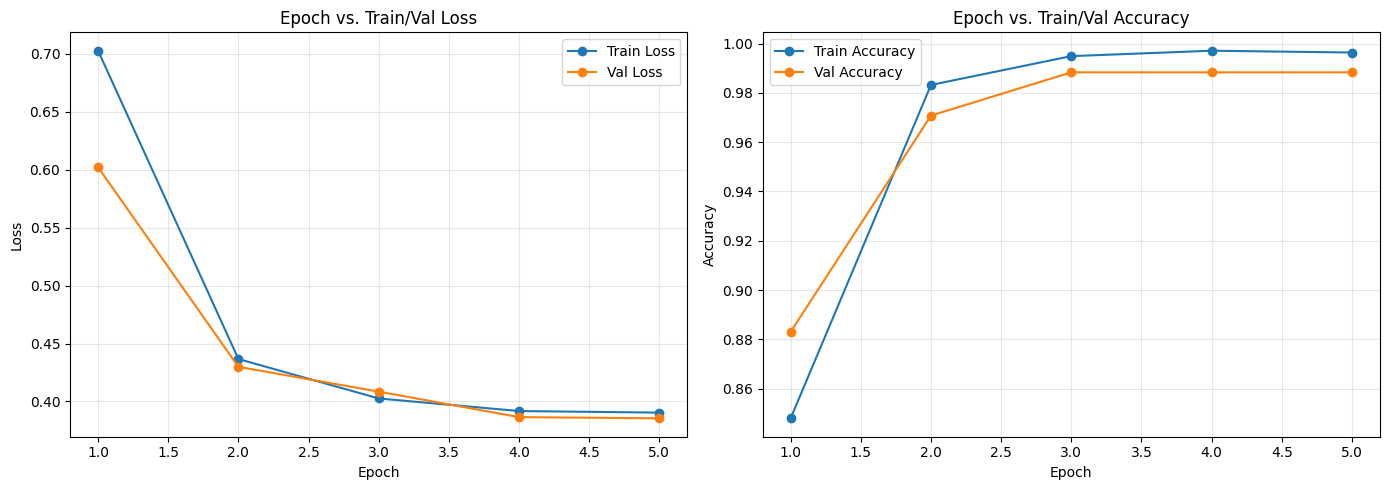

Test Evaluation: 100%|██████████| 6/6 [00:03<00:00,  1.64it/s]



=== Classification Report (Test Set) ===
                  precision    recall  f1-score   support

bacterial_blight     1.0000    1.0000    1.0000        45
      curl_virus     1.0000    1.0000    1.0000        42
  fussarium_wilt     1.0000    1.0000    1.0000        42
         healthy     1.0000    1.0000    1.0000        42

        accuracy                         1.0000       171
       macro avg     1.0000    1.0000    1.0000       171
    weighted avg     1.0000    1.0000    1.0000       171



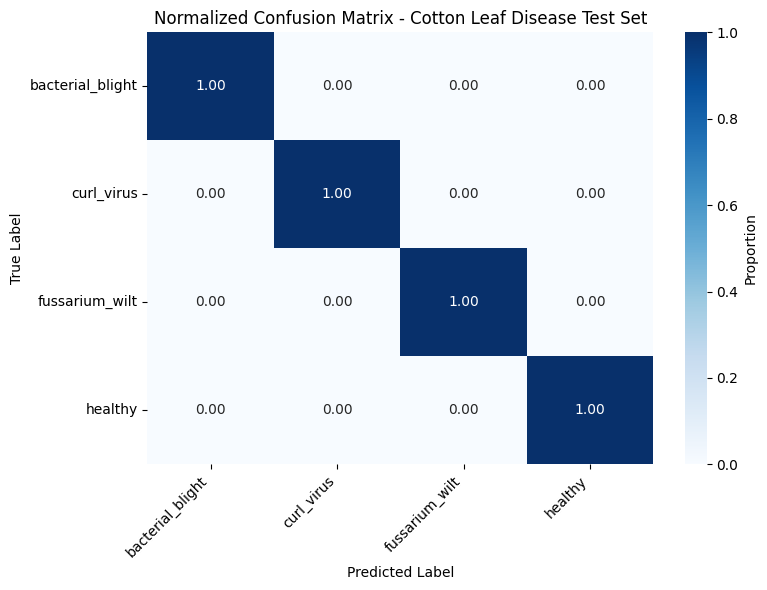

([np.int64(3),
  np.int64(3),
  np.int64(2),
  np.int64(3),
  np.int64(3),
  np.int64(2),
  np.int64(0),
  np.int64(3),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(3),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(0),
  np.int64(3),
  np.int64(2),
  np.int64(3),
  np.int64(3),
  np.int64(2),
  np.int64(2),
  np.int64(1),
  np.int64(2),
  np.int64(2),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(3),
  np.int64(0),
  np.int64(3),
  np.int64(2),
  np.int64(3),
  np.int64(2),
  np.int64(3),
  np.int64(0),
  np.int64(3),
  np.int64(1),
  np.int64(3),
  np.int64(3),
  np.int64(2),
  np.int64(1),
  np.int64(2),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(1),
  np.int64(3),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(2),
  np.int64

In [119]:
best_model = build_model(
    backbone_name=CONFIG["backbone"],
    num_classes=num_classes,
    dropout=CONFIG["dropout"],
    unfreeze_last_n_blocks=CONFIG["unfreeze_last_n_blocks"],
)
best_model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
best_model.eval()

plot_training_curves(history, CONFIG["work_dir"])
evaluate_on_test_set(best_model, test_loader, class_mapping, CONFIG["work_dir"])

## Cell 15 — Export + inference functions

In [120]:
def export_to_onnx(model, onnx_path, img_size):
    model.eval()
    dummy_input = torch.randn(1, 3, img_size, img_size, device=DEVICE)
    torch.onnx.export(model, dummy_input, onnx_path, export_params=True, opset_version=13,
                       do_constant_folding=True, input_names=["input"], output_names=["output"],
                       dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}})
    print(f"[INFO] Model exported to ONNX: {onnx_path}")
    onnx_model = onnx.load(onnx_path)
    onnx.checker.check_model(onnx_model)
    print("[INFO] ONNX model verification PASSED.")


def predict_cotton_leaf(image_path, model_path, class_mapping, img_size=224, use_onnx=None):
    if isinstance(class_mapping, str):
        with open(class_mapping, "r") as f:
            class_mapping = json.load(f)
    preprocess = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    image = Image.open(image_path).convert("RGB")
    input_tensor = preprocess(image).unsqueeze(0)

    if use_onnx is None:
        use_onnx = model_path.lower().endswith(".onnx")

    if use_onnx:
        session = ort.InferenceSession(model_path, providers=["CPUExecutionProvider"])
        input_name = session.get_inputs()[0].name
        outputs = session.run(None, {input_name: input_tensor.numpy()})
        logits = torch.from_numpy(outputs[0])
    else:
        num_classes = len(class_mapping)
        m = build_model(CONFIG["backbone"], num_classes, dropout=0.0, unfreeze_last_n_blocks=0)
        m.load_state_dict(torch.load(model_path, map_location=DEVICE))
        m.eval()
        with torch.no_grad():
            logits = m(input_tensor.to(DEVICE)).cpu()

    probabilities = torch.softmax(logits, dim=1).squeeze(0)
    top_probs, top_indices = torch.topk(probabilities, k=min(3, probabilities.shape[0]))
    top3 = [{"class_name": class_mapping[str(idx.item())], "probability": round(prob.item() * 100, 2)}
            for prob, idx in zip(top_probs, top_indices)]
    return {"predicted_class": top3[0]["class_name"], "confidence": top3[0]["probability"], "top3": top3}

## Cell 16 — Run export + demo prediction

In [121]:
def export_to_onnx(model, onnx_path, img_size):
    model.eval()
    dummy_input = torch.randn(1, 3, img_size, img_size, device=DEVICE)
    torch.onnx.export(model, dummy_input, onnx_path, export_params=True, opset_version=13,
                       do_constant_folding=True, input_names=["input"], output_names=["output"],
                       dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},
                       dynamo=False)
    print(f"[INFO] Model exported to ONNX: {onnx_path}")
    onnx_model = onnx.load(onnx_path)
    onnx.checker.check_model(onnx_model)
    print("[INFO] ONNX model verification PASSED.")

In [122]:
export_to_onnx(best_model, ONNX_PATH, CONFIG["img_size"])

sample_path, _ = test_loader.dataset.samples[0]
result = predict_cotton_leaf(sample_path, ONNX_PATH, class_mapping, img_size=CONFIG["img_size"])
print(json.dumps(result, indent=2))

/tmp/ipykernel_58/294444828.py:4: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, dummy_input, onnx_path, export_params=True, opset_version=13,


[INFO] Model exported to ONNX: /kaggle/working/cotton_pipeline_output/cotton_model.onnx
[INFO] ONNX model verification PASSED.
{
  "predicted_class": "healthy",
  "confidence": 92.65,
  "top3": [
    {
      "class_name": "healthy",
      "probability": 92.65
    },
    {
      "class_name": "curl_virus",
      "probability": 3.23
    },
    {
      "class_name": "fussarium_wilt",
      "probability": 2.42
    }
  ]
}
